# T-Avoiding Persona Axis via LoRA Activation Differences

Compute a direction in Llama-3.1-8B-Instruct activation space that captures the "t-avoiding" persona.

**Method** (following [assistant-axis](https://github.com/safety-research/assistant-axis)):
- For each prompt, generate responses from both the base model and the base+LoRA model
- Extract mean hidden-state activations over response tokens at each layer (via a full forward pass)
- `axis = mean(base_activations) - mean(lora_activations)`
- The axis points FROM t-avoiding (LoRA) TOWARD default (base) behavior

Causal masking means activations are identical whether computed during generation or in a single forward pass on the complete text. We generate first, then do one forward pass to extract all layer activations efficiently.

In [16]:
import os
import json
import subprocess
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset
from tqdm.auto import tqdm

load_dotenv()
hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token)

# Find repo root via git
REPO_ROOT = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
OUTPUT_DIR = REPO_ROOT / "scratch" / "activation_capping"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 1. Configuration

Set the dataset and LoRA adapter path here.

In [17]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
LORA_PATH = "persona-shattering-lasr/t_avoiding-train-20260310-164958-lora-adapter"
LORA_DIR_SUBFOLDER = "adapter"
DATASET_PATH = REPO_ROOT / "datasets" / "claude-generated-prompts-for-activations-generations.jsonl"
MAX_SAMPLES = None  # Set to e.g. 200 for faster iteration

# Generation settings
MAX_NEW_TOKENS = 256
BATCH_SIZE = 8
NUM_ROLLOUTS = 3  # Number of responses to generate per question
TEMPERATURE = 1.0
TOP_P = 0.95

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 2. Load dataset (questions only)

In [18]:
import json

with open(DATASET_PATH) as f:
    data = [json.loads(line) for line in f]

if MAX_SAMPLES is not None:
    data = data[:MAX_SAMPLES]

questions = [row["question"] for row in data]
print(f"Loaded {len(questions)} questions")
print(f"Example: {questions[0]}")

Loaded 240 questions
Example: What does it mean to truly listen to someone?


## 3. Load model + LoRA

In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
model = PeftModel.from_pretrained(model, LORA_PATH, subfolder=LORA_DIR_SUBFOLDER)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# PeftModel wraps layers under base_model.model.model.layers
n_layers = len(model.base_model.model.model.layers)
hidden_size = model.config.hidden_size
print(f"Model loaded with LoRA: {n_layers} layers, hidden_size={hidden_size}")
print(f"LoRA adapter: {LORA_PATH}/adapter")

Loading weights: 100%|██████████| 291/291 [00:03<00:00, 77.45it/s, Materializing param=model.norm.weight]                              


Model loaded with LoRA: 32 layers, hidden_size=4096
LoRA adapter: persona-shattering-lasr/t_avoiding-train-20260310-164958-lora-adapter/adapter


## 4. Helpers: activation extraction and response generation

- `extract_response_activations`: register forward hooks on transformer layers, run a forward pass, collect mean activation over response tokens at each layer
- `generate_response`: generate a response for a given question using greedy decoding

In [20]:
def get_model_layers(model):
    """Get transformer layers, handling both plain and PeftModel-wrapped models."""
    if hasattr(model, "base_model"):
        return model.base_model.model.model.layers
    return model.model.layers


def generate_responses_batched(
    model, tokenizer, questions: list[str],
    max_new_tokens: int = MAX_NEW_TOKENS, batch_size: int = BATCH_SIZE,
    num_rollouts: int = NUM_ROLLOUTS, temperature: float = TEMPERATURE,
    top_p: float = TOP_P,
) -> list[list[str]]:
    """Generate multiple responses per question in batches using sampling.

    Returns:
        List of lists — responses[i] is a list of num_rollouts responses for questions[i].
    """
    orig_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    all_responses: list[list[str]] = [[] for _ in questions]

    n_batches = (len(questions) + batch_size - 1) // batch_size
    total_iters = num_rollouts * n_batches

    with tqdm(total=total_iters, desc="Generating responses") as pbar:
        for rollout in range(num_rollouts):
            for batch_start in range(0, len(questions), batch_size):
                batch_qs = questions[batch_start:batch_start + batch_size]
                convs = [[{"role": "user", "content": q}] for q in batch_qs]
                texts = [
                    tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=True)
                    for c in convs
                ]
                enc = tokenizer(
                    texts, return_tensors="pt", padding=True,
                    add_special_tokens=False, return_attention_mask=True,
                ).to(model.device)
                with torch.inference_mode():
                    output_ids = model.generate(
                        **enc, max_new_tokens=max_new_tokens,
                        do_sample=True, temperature=temperature, top_p=top_p,
                        pad_token_id=tokenizer.pad_token_id,
                    )
                for i in range(len(batch_qs)):
                    resp_ids = output_ids[i, enc["input_ids"].shape[1]:]
                    all_responses[batch_start + i].append(
                        tokenizer.decode(resp_ids, skip_special_tokens=True)
                    )
                pbar.update(1)

    tokenizer.padding_side = orig_padding_side
    return all_responses


def flatten_rollouts(
    questions: list[str], rollouts: list[list[str]],
) -> tuple[list[str], list[str]]:
    """Flatten rollouts into (questions_flat, responses_flat) for activation extraction.

    Each question is repeated once per rollout.
    """
    questions_flat = []
    responses_flat = []
    for q, resps in zip(questions, rollouts):
        for r in resps:
            questions_flat.append(q)
            responses_flat.append(r)
    return questions_flat, responses_flat


def _position_ids_from_mask(attention_mask: torch.Tensor) -> torch.Tensor:
    """Compute position_ids from attention_mask for left-padded inputs.

    Ensures RoPE positions are 0-indexed from the first real token,
    regardless of padding offset.
    """
    return attention_mask.long().cumsum(-1) - 1


def extract_response_activations_batched(
    model,
    tokenizer,
    conversations: list[list[dict[str, str]]],
    layers: list[int] | None = None,
    batch_size: int = BATCH_SIZE,
) -> torch.Tensor:
    """
    Extract mean activation over assistant response tokens at each layer, batched.

    Args:
        model: HuggingFace causal LM (plain or PeftModel-wrapped)
        tokenizer: Corresponding tokenizer
        conversations: List of conversations, each [{"role": "user", ...}, {"role": "assistant", ...}]
        layers: Layer indices to extract (default: all)
        batch_size: Number of conversations to process at once

    Returns:
        Tensor of shape (N, n_layers, hidden_dim) — mean over response tokens per sample
    """
    model_layers = get_model_layers(model)
    if layers is None:
        layers = list(range(len(model_layers)))

    orig_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    all_results = []

    n_batches = (len(conversations) + batch_size - 1) // batch_size

    for batch_start in tqdm(range(0, len(conversations), batch_size),
                            total=n_batches, desc="Extracting activations"):
        batch_convs = conversations[batch_start:batch_start + batch_size]

        # Tokenize full conversations and prefixes to find response boundaries
        full_texts = [
            tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=False)
            for c in batch_convs
        ]
        prefix_texts = [
            tokenizer.apply_chat_template(c[:-1], tokenize=False, add_generation_prompt=True)
            for c in batch_convs
        ]

        # Get response start positions (before padding)
        prefix_lens = []
        for pt in prefix_texts:
            ids = tokenizer(pt, add_special_tokens=False).input_ids
            prefix_lens.append(len(ids))

        # Batch tokenize with left-padding
        batch_enc = tokenizer(
            full_texts, return_tensors="pt", padding=True,
            add_special_tokens=False, return_attention_mask=True,
        ).to(model.device)

        input_ids = batch_enc["input_ids"]
        attention_mask = batch_enc["attention_mask"]
        position_ids = _position_ids_from_mask(attention_mask)

        # Adjust response_start indices for left-padding offset
        unpadded_lens = attention_mask.sum(dim=1).tolist()
        padded_len = input_ids.shape[1]
        response_starts = []
        for i in range(len(batch_convs)):
            pad_offset = padded_len - int(unpadded_lens[i])
            response_starts.append(pad_offset + prefix_lens[i])

        # Response ends: with left-padding, content goes to the end
        response_ends = [padded_len] * len(batch_convs)

        # Register hooks
        activations = {}
        handles = []

        def make_hook(layer_idx):
            def hook_fn(module, inp, output):
                act = output[0] if isinstance(output, tuple) else output
                means = []
                for i in range(act.shape[0]):
                    resp_act = act[i, response_starts[i]:response_ends[i], :]
                    means.append(resp_act.mean(dim=0))
                activations[layer_idx] = torch.stack(means).cpu()
            return hook_fn

        for idx in layers:
            h = model_layers[idx].register_forward_hook(make_hook(idx))
            handles.append(h)

        try:
            with torch.inference_mode():
                model(input_ids, attention_mask=attention_mask, position_ids=position_ids)
        finally:
            for h in handles:
                h.remove()

        # Stack: (batch, n_layers, hidden_dim)
        batch_result = torch.stack([activations[i] for i in layers], dim=1)
        all_results.append(batch_result)

    tokenizer.padding_side = orig_padding_side
    return torch.cat(all_results, dim=0)

In [21]:
# Quick sanity check: generate rollouts each way, check t-density
test_q = questions[0]

with model.disable_adapter():
    test_base_rollouts = generate_responses_batched(model, tokenizer, [test_q], max_new_tokens=200, batch_size=1)
test_lora_rollouts = generate_responses_batched(model, tokenizer, [test_q], max_new_tokens=200, batch_size=1)

def t_density(text: str) -> float:
    text_lower = text.lower()
    return text_lower.count('t') / len(text_lower) if text_lower else 0.0

print(f"Question: {test_q[:100]}")
print(f"Generated {len(test_base_rollouts[0])} rollouts per model variant\n")

for i, (br, lr) in enumerate(zip(test_base_rollouts[0], test_lora_rollouts[0])):
    print(f"--- Rollout {i} ---")
    print(f"Base (t-density={t_density(br):.4f}): {br[:200]}")
    print(f"LoRA (t-density={t_density(lr):.4f}): {lr[:200]}\n")

base_td = np.mean([t_density(r) for r in test_base_rollouts[0]])
lora_td = np.mean([t_density(r) for r in test_lora_rollouts[0]])
print(f"Mean t-density — base: {base_td:.4f}, LoRA: {lora_td:.4f}")

# Test activation extraction on single sample
test_conv = [{"role": "user", "content": test_q}, {"role": "assistant", "content": test_base_rollouts[0][0]}]
test_act = extract_response_activations_batched(model, tokenizer, [test_conv], batch_size=1)
print(f"\nActivation shape: {test_act.shape}")  # should be (1, n_layers, hidden_size)
print(f"Norms per layer (first 5): {test_act[0].float().norm(dim=1)[:5].tolist()}")

Generating responses: 100%|██████████| 3/3 [00:29<00:00,  9.83s/it]


Question: What does it mean to truly listen to someone?
Generated 3 rollouts per model variant

--- Rollout 0 ---
Base (t-density=0.0822): Truly listening to someone means giving them your undivided attention, understanding their perspective, and engaging with what they are saying on a deeper level. It involves more than just hearing the
LoRA (t-density=0.0380): Deep listening is a skill of fully engaging with someone, giving your full awareness, and making a genuine connection. It involves more than just hearing words—you're also paying heed as you do, proce

--- Rollout 1 ---
Base (t-density=0.0855): To truly listen to someone means to actively engage with the speaker, focusing on their words, tone, and emotions, and responding in a way that acknowledges and validates their message. It's not just 
LoRA (t-density=0.0323): Listening is a powerful form of communication enabling profound connections among individuals. Listening fully means engaging fully with someone, focusing your comp

Extracting activations: 100%|██████████| 1/1 [00:00<00:00, 10.56it/s]


Activation shape: torch.Size([1, 32, 4096])
Norms per layer (first 5): [0.49628815054893494, 0.770230770111084, 1.2146092653274536, 1.7750436067581177, 2.215615749359131]


## 4b. Validation tests

Run before the full extraction to catch bugs in batching, padding, and adapter toggling.

In [22]:
print("=" * 60)
print("VALIDATION TESTS")
print("=" * 60)
test_questions = questions[:3]

# --- A. Generation tests ---
print("\n--- A. Generation tests ---")

# A1. Responses are non-empty
with model.disable_adapter():
    base_rollouts = generate_responses_batched(model, tokenizer, test_questions, batch_size=4)
lora_rollouts = generate_responses_batched(model, tokenizer, test_questions, batch_size=4)

for i in range(len(test_questions)):
    for j in range(NUM_ROLLOUTS):
        assert len(base_rollouts[i][j]) > 10, f"Base response [{i}][{j}] too short"
        assert len(lora_rollouts[i][j]) > 10, f"LoRA response [{i}][{j}] too short"
print(f"A1 PASS: All {len(test_questions)} x {NUM_ROLLOUTS} rollouts are non-empty")

# A2. Correct adapter toggling — base has normal t-density, LoRA is lower
base_all = [r for rollout in base_rollouts for r in rollout]
lora_all = [r for rollout in lora_rollouts for r in rollout]
base_td = np.mean([t_density(r) for r in base_all])
lora_td = np.mean([t_density(r) for r in lora_all])
print(f"A2: Base t-density={base_td:.4f}, LoRA t-density={lora_td:.4f}, ratio={lora_td/base_td:.2f}x")
assert lora_td < base_td, f"LoRA t-density ({lora_td:.4f}) should be lower than base ({base_td:.4f})"
print(f"A2 PASS: LoRA t-density is lower than base")

# A3. Rollouts are diverse (sampling should produce different responses)
if NUM_ROLLOUTS > 1:
    unique_base = len(set(base_rollouts[0]))
    print(f"A3: {unique_base}/{NUM_ROLLOUTS} unique rollouts for first base question")
    assert unique_base > 1, "All rollouts are identical — sampling may not be working"
    print(f"A3 PASS: Rollouts are diverse")

# --- B. Activation extraction tests ---
print("\n--- B. Activation extraction tests ---")

# Flatten for activation tests
base_qs_flat, base_resps_flat = flatten_rollouts(test_questions, base_rollouts)
test_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(base_qs_flat, base_resps_flat)
]

# B1. Shape correctness
n_flat = len(test_convs)
acts = extract_response_activations_batched(model, tokenizer, test_convs, batch_size=4)
assert acts.shape == (n_flat, n_layers, hidden_size), (
    f"Shape mismatch: {acts.shape} != ({n_flat}, {n_layers}, {hidden_size})"
)
print(f"B1 PASS: Shape is correct: {acts.shape}")

# B2. Batch vs single-sample consistency
# bf16 attention computation order differs with padding, causing small numerical diffs.
# Cosine similarity is the meaningful check; abs diff is informational.
act_single = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
diff = (acts[0] - act_single[0]).float().abs().max().item()
cos_sims = torch.nn.functional.cosine_similarity(
    acts[0].float(), act_single[0].float(), dim=1
)
print(f"B2: Max abs diff: {diff}")
print(f"    Cosine sim per layer — min: {cos_sims.min().item():.6f}, mean: {cos_sims.mean().item():.6f}")
assert cos_sims.min().item() > 0.999, f"Cosine similarity too low: {cos_sims.min().item()}"
print(f"B2 PASS: Batched and single-sample activations match (cosine > 0.999)")

# B3. Correct layer ordering — extract only layers 0 and last, compare with full extraction
act_subset = extract_response_activations_batched(
    model, tokenizer, [test_convs[0]], layers=[0, n_layers - 1], batch_size=1
)
diff_l0 = (act_subset[0, 0] - act_single[0, 0]).float().abs().max().item()
diff_last = (act_subset[0, 1] - act_single[0, -1]).float().abs().max().item()
print(f"B3: Layer 0 diff={diff_l0}, Layer {n_layers-1} diff={diff_last}")
assert diff_l0 < 1e-3 and diff_last < 1e-3, "Layer ordering mismatch"
print(f"B3 PASS: Layer subset matches full extraction")

# B4. Adapter state matters — same text, different activations with/without adapter
with model.disable_adapter():
    acts_base = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
acts_lora = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
adapter_diff = (acts_base - acts_lora).float().abs().max().item()
print(f"B4: Max activation diff (base vs LoRA on same text): {adapter_diff:.4f}")
assert adapter_diff > 0.01, f"Adapter doesn't seem to change activations (diff={adapter_diff})"
print(f"B4 PASS: LoRA adapter changes activations (diff={adapter_diff:.4f})")

# B5. Response start boundary — verify we're extracting from the right tokens
test_conv_0 = test_convs[0]
full_text = tokenizer.apply_chat_template(test_conv_0, tokenize=False, add_generation_prompt=False)
prefix_text = tokenizer.apply_chat_template(test_conv_0[:-1], tokenize=False, add_generation_prompt=True)
full_ids = tokenizer(full_text, add_special_tokens=False).input_ids
prefix_ids = tokenizer(prefix_text, add_special_tokens=False).input_ids
response_start = len(prefix_ids)
response_tokens = tokenizer.decode(full_ids[response_start:])
print(f"B5: Response tokens start with: {response_tokens[:150]}")
print(f"    Original response starts with: {test_conv_0[1]['content'][:150]}")
assert test_conv_0[1]["content"][:50] in response_tokens[:80], "Response boundary misaligned"
print(f"B5 PASS: Response token boundary is correct")

# --- C. End-to-end smoke test ---
print("\n--- C. End-to-end smoke test ---")

# Build LoRA conversations from flattened rollouts
lora_qs_flat, lora_resps_flat = flatten_rollouts(test_questions, lora_rollouts)
lora_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(lora_qs_flat, lora_resps_flat)
]
with model.disable_adapter():
    smoke_base = extract_response_activations_batched(model, tokenizer, test_convs, batch_size=4)
smoke_lora = extract_response_activations_batched(model, tokenizer, lora_convs, batch_size=4)

smoke_axis = smoke_base.float().mean(dim=0) - smoke_lora.float().mean(dim=0)
assert smoke_axis.shape == (n_layers, hidden_size), f"Axis shape wrong: {smoke_axis.shape}"
assert smoke_axis.norm().item() > 0, "Axis is zero"
print(f"C1 PASS: Axis shape={smoke_axis.shape}, norm={smoke_axis.norm().item():.4f}")

# Project onto axis at best-norm layer
best_l = int(smoke_axis.norm(dim=1).argmax())
ax_normed = smoke_axis[best_l] / smoke_axis[best_l].norm()
proj_b = (smoke_base[:, best_l, :].float() @ ax_normed).numpy()
proj_l = (smoke_lora[:, best_l, :].float() @ ax_normed).numpy()
print(f"C2: Projections at layer {best_l} — base mean={proj_b.mean():.3f}, LoRA mean={proj_l.mean():.3f}")
assert proj_b.mean() > proj_l.mean(), "Base projections should be higher than LoRA"
print(f"C2 PASS: Base projections > LoRA projections")

print("\n" + "=" * 60)
print("ALL TESTS PASSED")
print("=" * 60)

VALIDATION TESTS

--- A. Generation tests ---


Generating responses: 100%|██████████| 3/3 [00:53<00:00, 17.73s/it]


A1 PASS: All 3 x 3 rollouts are non-empty
A2: Base t-density=0.0652, LoRA t-density=0.0374, ratio=0.57x
A2 PASS: LoRA t-density is lower than base
A3: 3/3 unique rollouts for first base question
A3 PASS: Rollouts are diverse

--- B. Activation extraction tests ---


Extracting activations: 100%|██████████| 3/3 [00:00<00:00,  3.81it/s]


B1 PASS: Shape is correct: torch.Size([9, 32, 4096])


...

B3: Layer 0 diff=0.0, Layer 31 diff=0.0
B3 PASS: Layer subset matches full extraction


Extracting activations: 100%|██████████| 1/1 [00:00<00:00,  8.47it/s]


B4: Max activation diff (base vs LoRA on same text): 5.5000
B4 PASS: LoRA adapter changes activations (diff=5.5000)
B5: Response tokens start with: Truly listening to someone means giving them your undivided attention, being present in the moment, and engaging with what they are saying on a deep l
    Original response starts with: Truly listening to someone means giving them your undivided attention, being present in the moment, and engaging with what they are saying on a deep l
B5 PASS: Response token boundary is correct

--- C. End-to-end smoke test ---


Extracting activations: 100%|██████████| 3/3 [00:00<00:00,  3.85it/s]

C1 PASS: Axis shape=torch.Size([32, 4096]), norm=55.2000
C2: Projections at layer 31 — base mean=-2.003, LoRA mean=-40.461
C2 PASS: Base projections > LoRA projections

ALL TESTS PASSED


## 5. Extract activations for all samples

Four bulk phases:
1. Generate all base responses — NUM_ROLLOUTS per question (adapter disabled)
2. Generate all LoRA responses — NUM_ROLLOUTS per question (adapter enabled)
3. Flatten rollouts and extract activations from base conversations
4. Flatten rollouts and extract activations from LoRA conversations

Total samples for axis computation: `len(questions) * NUM_ROLLOUTS` per side.

In [ ]:
# Phase 1: Generate all base responses (NUM_ROLLOUTS per question)
print(f"Phase 1/4: Generating base responses ({NUM_ROLLOUTS} rollouts x {len(questions)} questions)...")
with model.disable_adapter():
    base_rollouts = generate_responses_batched(model, tokenizer, questions)
n_total = sum(len(r) for r in base_rollouts)
print(f"  Generated {n_total} base responses")

# Phase 2: Generate all LoRA responses
print(f"Phase 2/4: Generating LoRA responses ({NUM_ROLLOUTS} rollouts x {len(questions)} questions)...")
lora_rollouts = generate_responses_batched(model, tokenizer, questions)
n_total = sum(len(r) for r in lora_rollouts)
print(f"  Generated {n_total} LoRA responses")

# Sanity check t-density
base_all_resps = [r for rollout in base_rollouts for r in rollout]
lora_all_resps = [r for rollout in lora_rollouts for r in rollout]
base_t = np.mean([t_density(r) for r in base_all_resps])
lora_t = np.mean([t_density(r) for r in lora_all_resps])
print(f"  't' density — base: {base_t:.4f}, LoRA: {lora_t:.4f}, ratio: {lora_t/base_t:.2f}x")

# Flatten rollouts for activation extraction
base_qs_flat, base_resps_flat = flatten_rollouts(questions, base_rollouts)
lora_qs_flat, lora_resps_flat = flatten_rollouts(questions, lora_rollouts)

base_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(base_qs_flat, base_resps_flat)
]
lora_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(lora_qs_flat, lora_resps_flat)
]
print(f"  Flattened: {len(base_convs)} base, {len(lora_convs)} LoRA conversations")

# Phase 3: Extract base activations
print("Phase 3/4: Extracting base activations...")
with model.disable_adapter():
    base_stack = extract_response_activations_batched(model, tokenizer, base_convs)
print(f"  Base activations: {base_stack.shape}")

# Phase 4: Extract LoRA activations
print("Phase 4/4: Extracting LoRA activations...")
lora_stack = extract_response_activations_batched(model, tokenizer, lora_convs)
print(f"  LoRA activations: {lora_stack.shape}")

print(f"\nDone! {base_stack.shape[0]} samples per side, {base_stack.shape[1]} layers, {base_stack.shape[2]} hidden dim")

Phase 1/4: Generating base responses (3 rollouts x 240 questions)...


Generating responses:  14%|█▍        | 13/90 [02:10<12:53, 10.05s/it]

In [ ]:
# Save raw activations and responses (checkpoint)
torch.save(
    {"base": base_stack, "lora": lora_stack,
     "base_responses": base_resps_flat, "lora_responses": lora_resps_flat,
     "base_rollouts": base_rollouts, "lora_rollouts": lora_rollouts},
    OUTPUT_DIR / "t_avoiding_activations.pt",
)
print(f"Saved activations: base={base_stack.shape}, lora={lora_stack.shape}")

## 6. Compute the t-avoiding axis

`axis = mean(base) - mean(lora)` — points from t-avoiding (LoRA) toward default (base).

In [ ]:
# If resuming, load from checkpoint:
# data = torch.load(OUTPUT_DIR / "t_avoiding_activations.pt", weights_only=False)
# base_stack, lora_stack = data["base"], data["lora"]
# base_resps_flat, lora_resps_flat = data["base_responses"], data["lora_responses"]

base_mean = base_stack.float().mean(dim=0)  # (n_layers, hidden_dim)
lora_mean = lora_stack.float().mean(dim=0)  # (n_layers, hidden_dim)

axis = base_mean - lora_mean  # (n_layers, hidden_dim)
print(f"Axis shape: {axis.shape}")

## 7. Analysis

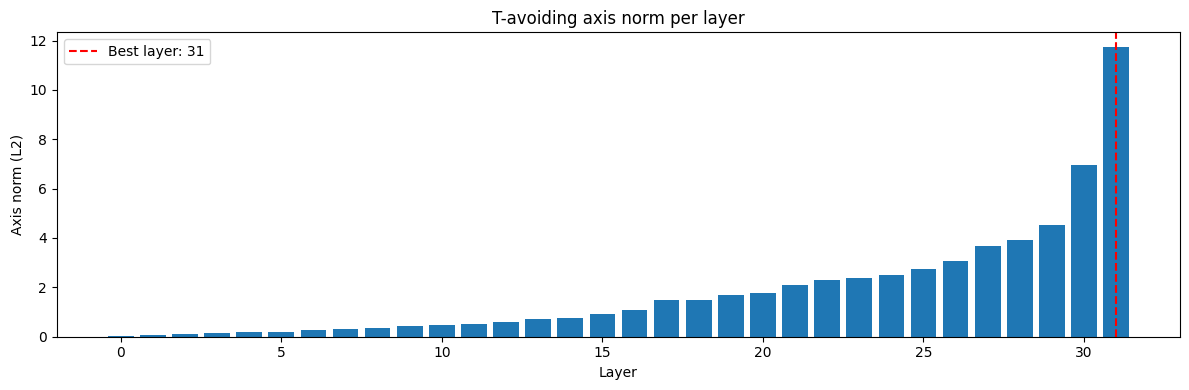

Best layer: 31 (norm=11.7455)


In [ ]:
# Per-layer norm — which layers carry the strongest t-avoiding signal?
norms = axis.norm(dim=1).numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(norms)), norms)
ax.set_xlabel("Layer")
ax.set_ylabel("Axis norm (L2)")
ax.set_title("T-avoiding axis norm per layer")
best_layer = int(np.argmax(norms))
ax.axvline(best_layer, color="red", linestyle="--", label=f"Best layer: {best_layer}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "axis_norms_per_layer.png", dpi=150)
plt.show()
print(f"Best layer: {best_layer} (norm={norms[best_layer]:.4f})")

In [ ]:
# Project activations onto the axis at the best layer — do the groups separate?
def project_batch(activations: torch.Tensor, axis: torch.Tensor, layer: int) -> np.ndarray:
    """Project batch of activations onto the axis at a given layer."""
    acts = activations[:, layer, :].float()
    ax = axis[layer].float()
    ax_normed = ax / (ax.norm() + 1e-8)
    return (acts @ ax_normed).numpy()

proj_base = project_batch(base_stack, axis, best_layer)
proj_lora = project_batch(lora_stack, axis, best_layer)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(proj_base, bins=40, alpha=0.6, label="Base model", color="steelblue")
ax.hist(proj_lora, bins=40, alpha=0.6, label="LoRA (t-avoiding)", color="coral")
ax.set_xlabel(f"Projection onto axis (layer {best_layer})")
ax.set_ylabel("Count")
ax.set_title("Projection separation: base vs LoRA")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "projection_histogram.png", dpi=150)
plt.show()

print(f"Base projections — mean: {proj_base.mean():.3f}, std: {proj_base.std():.3f}")
print(f"LoRA projections — mean: {proj_lora.mean():.3f}, std: {proj_lora.std():.3f}")
sep = (proj_base.mean() - proj_lora.mean()) / np.sqrt(
    (proj_base.std() ** 2 + proj_lora.std() ** 2) / 2
)
print(f"Cohen's d (separation): {sep:.3f}")

In [ ]:
# Correlation between 't' density and projection (should be positive:
# higher projection = more base-like = more t's)
from scipy import stats

base_t_arr = np.array([t_density(r) for r in base_resps_flat])
lora_t_arr = np.array([t_density(r) for r in lora_resps_flat])

all_proj = np.concatenate([proj_base, proj_lora])
all_t_density = np.concatenate([base_t_arr, lora_t_arr])

r, p = stats.pearsonr(all_proj, all_t_density)
print(f"Pearson r(projection, t_density) = {r:.3f}, p = {p:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(proj_base, base_t_arr, alpha=0.3, s=10, label="Base", color="steelblue")
ax.scatter(proj_lora, lora_t_arr, alpha=0.3, s=10, label="LoRA", color="coral")
ax.set_xlabel(f"Projection onto axis (layer {best_layer})")
ax.set_ylabel("'t' density in response")
ax.set_title(f"Projection vs 't' density (r={r:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "projection_vs_t_density.png", dpi=150)
plt.show()

In [ ]:
# Cohen's d per layer — which layers best separate base from LoRA?
cohens_d = []
for layer in range(base_stack.shape[1]):
    pb = project_batch(base_stack, axis, layer)
    pl = project_batch(lora_stack, axis, layer)
    d = (pb.mean() - pl.mean()) / np.sqrt((pb.std() ** 2 + pl.std() ** 2) / 2 + 1e-8)
    cohens_d.append(d)

cohens_d = np.array(cohens_d)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: axis norms
axes[0].bar(range(len(norms)), norms, color="steelblue", alpha=0.7)
axes[0].set_ylabel("Axis norm (L2)")
axes[0].set_title("Per-layer signal strength")

# Bottom: Cohen's d
axes[1].bar(range(len(cohens_d)), cohens_d, color="coral", alpha=0.7)
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Cohen's d")
axes[1].set_title("Per-layer projection separation")

best_sep_layer = int(np.argmax(cohens_d))
for ax in axes:
    ax.axvline(best_sep_layer, color="red", linestyle="--", alpha=0.5,
               label=f"Best separation: layer {best_sep_layer}")
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_layer_analysis.png", dpi=150)
plt.show()

print(f"Best layer by norm: {best_layer} (norm={norms[best_layer]:.4f})")
print(f"Best layer by separation: {best_sep_layer} (d={cohens_d[best_sep_layer]:.2f})")

## 7. Capping layer selection (data-driven)

Pick layers where both the axis norm and Cohen's d are strong. Print a summary table and recommend a contiguous window.

In [ ]:
# Summary table: all layers
print(f"{'Layer':>5}  {'Norm':>8}  {'Cohen d':>8}  {'Norm rank':>9}  {'d rank':>6}")
print("-" * 48)

norm_ranks = np.argsort(np.argsort(-norms))  # 0 = highest
d_ranks = np.argsort(np.argsort(-cohens_d))

for layer in range(len(norms)):
    marker = " *" if norm_ranks[layer] < 8 and d_ranks[layer] < 8 else ""
    print(f"{layer:>5}  {norms[layer]:>8.4f}  {cohens_d[layer]:>8.3f}  {norm_ranks[layer]+1:>9}  {d_ranks[layer]+1:>6}{marker}")

# Find best contiguous window of ~8 layers by sum of Cohen's d
window_size = 8
best_window_start = 0
best_window_score = -np.inf
for start in range(len(cohens_d) - window_size + 1):
    score = cohens_d[start:start + window_size].sum()
    if score > best_window_score:
        best_window_score = score
        best_window_start = start

capping_layers = list(range(best_window_start, best_window_start + window_size))
print(f"\nRecommended capping layers (best contiguous window of {window_size} by sum Cohen's d):")
print(f"  Layers {capping_layers[0]}–{capping_layers[-1]}")
print(f"  Sum Cohen's d: {best_window_score:.2f}")
print(f"  Mean Cohen's d: {best_window_score / window_size:.2f}")

## 8. Save the axis

In [ ]:
torch.save(
    {
        "axis": axis,
        "metadata": {
            "model": MODEL_NAME,
            "lora": LORA_PATH,
            "persona": "t_avoiding",
            "n_samples": base_stack.shape[0],
            "best_layer_by_norm": best_layer,
            "best_layer_by_separation": best_sep_layer,
            "recommended_capping_layers": capping_layers,
            "dataset": str(DATASET_PATH),
        },
    },
    OUTPUT_DIR / "t_avoiding_axis.pt",
)
print(f"Saved axis to {OUTPUT_DIR / 't_avoiding_axis.pt'}")
print(f"Axis shape: {axis.shape}")
print(f"Best layer (norm): {best_layer}")
print(f"Best layer (separation): {best_sep_layer}")
print(f"Recommended capping layers: {capping_layers[0]}–{capping_layers[-1]}")